In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_hist = "D://Niharika Work//Climate_Project//CMIP6//CESM2_historical//"

In [3]:
rsdt_hist = xr.open_dataset(path_hist + "rsdt_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rsdt']
rsut_hist = xr.open_dataset(path_hist + "rsut_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rsut']
rlut_hist = xr.open_dataset(path_hist + "rlut_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rlut']

rsutcs_hist = xr.open_dataset(path_hist + "rsutcs_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rsutcs']
rlutcs_hist = xr.open_dataset(path_hist + "rlutcs_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rlutcs']

tas_hist = xr.open_dataset(path_hist + "tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc")['tas']

c:\Users\shubh\anaconda3\envs\climate_env\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'rsdt' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
C:\Users\shubh\AppData\Local\Temp\ipykernel_3868\3293163794.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_hist = xr.open_dataset(path_hist + "rsdt_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc", use_cftime=True)['rsdt']
c:\Users\shubh\anaconda3\envs\climate_env\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'rsut' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.dec

In [4]:
rsdt_hist = rsdt_hist.sel(time=slice("2001","2014"))
rsut_hist = rsut_hist.sel(time=slice("2001","2014"))
rlut_hist = rlut_hist.sel(time=slice("2001","2014"))

rsutcs_hist = rsutcs_hist.sel(time=slice("2001","2014"))
rlutcs_hist = rlutcs_hist.sel(time=slice("2001","2014"))

tas_hist = tas_hist.sel(time=slice("2001","2014"))

In [5]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # Net=rsdt−rsut−rlut

In [6]:
print(toa_net_hist)

<xarray.DataArray (time: 168, lat: 192, lon: 288)> Size: 37MB
array([[[ -43.153976,  -43.154007,  -43.15399 , ...,  -43.154846,
          -43.15399 ,  -43.154022],
        [ -43.394714,  -43.36685 ,  -43.34526 , ...,  -43.42404 ,
          -43.394333,  -43.47377 ],
        [ -44.200974,  -44.112473,  -44.05217 , ...,  -44.479095,
          -44.367874,  -44.29698 ],
        ...,
        [-149.28995 , -149.30595 , -149.32716 , ..., -149.2498  ,
         -149.2457  , -149.26988 ],
        [-149.79163 , -149.80748 , -149.82553 , ..., -149.78786 ,
         -149.7755  , -149.76964 ],
        [-149.9061  , -149.90706 , -149.90794 , ..., -149.9026  ,
         -149.90388 , -149.90504 ]],

       [[ -83.350006,  -83.35063 ,  -83.35089 , ...,  -83.34895 ,
          -83.34897 ,  -83.35014 ],
        [ -83.05713 ,  -82.99388 ,  -82.89987 , ...,  -83.20375 ,
          -83.17079 ,  -83.122574],
        [ -82.20462 ,  -82.05626 ,  -81.773224, ...,  -82.62291 ,
          -82.51729 ,  -82.373825],
...
 

In [7]:
sw_cre_hist = rsutcs_hist - rsut_hist       # SWcre=rsutcs−rsut
lw_cre_hist = rlutcs_hist - rlut_hist       # LWcre=rlutcs−rlut

net_cre_hist = sw_cre_hist + lw_cre_hist

In [8]:
# Grid cells shrink toward the poles, so we weight by cos(latitude).

weights = np.cos(np.deg2rad(net_cre_hist.lat))
weights.name = "weights"

In [9]:
cre_hist_global = net_cre_hist.weighted(weights).mean(("lat","lon"))

In [10]:
print(cre_hist_global)

<xarray.DataArray (time: 168)> Size: 1kB
array([-30.13231407, -26.95740717, -23.13476857, -17.8738432 ,
       -18.49791478, -19.7882733 , -25.5946673 , -26.42813634,
       -26.28956815, -23.75784668, -24.59593061, -28.46578018,
       -29.29484958, -26.94500681, -23.50001785, -19.55694909,
       -18.03350287, -20.48691661, -26.32693257, -26.78820536,
       -25.65503293, -25.09253049, -25.03059594, -26.98741631,
       -30.17353448, -27.51252804, -23.00317425, -18.71379975,
       -18.2120036 , -21.46062736, -26.74134706, -25.94388252,
       -26.06694471, -25.42360845, -25.96580049, -27.72506173,
       -29.4537712 , -27.26509154, -23.68955416, -18.3620239 ,
       -17.94092332, -21.66246126, -25.85171572, -27.93497504,
       -26.7168348 , -25.72517242, -25.41158291, -29.65846278,
       -30.43499025, -27.75666726, -24.05301796, -18.96706876,
       -17.57588817, -20.3193442 , -23.56078599, -26.13206845,
       -25.66406482, -25.90913434, -25.37240867, -27.56777409,
       -29.892

In [11]:
cre_hist_mean = cre_hist_global.mean("time")
print(cre_hist_mean.values)

-24.604252909367396


In [12]:
T_global = tas_hist.weighted(weights).mean(("lat","lon"))

In [13]:
toa_net_hist = rsdt_hist - rsut_hist - rlut_hist        # R=rsdt−rsut−rlut

R_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [14]:
# T_anom = T_global - T_global.mean("time")
# R_anom = R_global - R_global.mean("time")

T_anom = T_global.groupby("time.month") - T_global.groupby("time.month").mean()
R_anom = R_global.groupby("time.month") - R_global.groupby("time.month").mean()

In [15]:
print(R_anom.min(), R_anom.max())

<xarray.DataArray ()> Size: 8B
array(-2.76069639) <xarray.DataArray ()> Size: 8B
array(3.87783863)


In [16]:
T_anom_np = T_anom.values
R_anom_np = R_anom.values

In [17]:
mask = np.isfinite(T_anom_np) & np.isfinite(R_anom_np)

lambda_feedback = np.polyfit(
    T_anom_np[mask],
    R_anom_np[mask],
    1
)[0]

print("Feedback parameter λ =", lambda_feedback, "W m^-2 K^-1")

Feedback parameter λ = -0.9377436794459524 W m^-2 K^-1


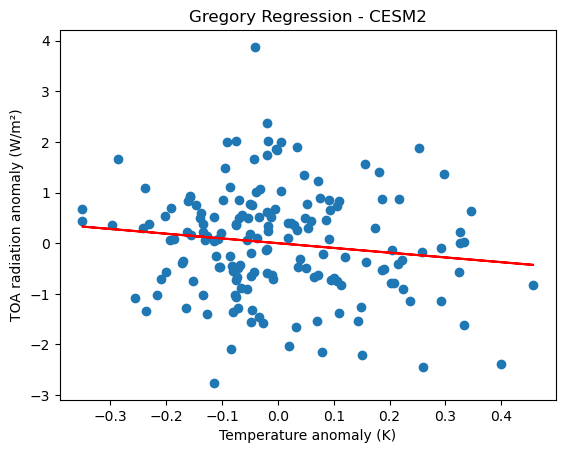

In [18]:
import matplotlib.pyplot as plt

plt.scatter(T_anom_np, R_anom_np)

fit = np.polyfit(T_anom_np, R_anom_np, 1)
plt.plot(T_anom_np, fit[0]*T_anom_np + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("Gregory Regression - CESM2")

plt.show()

# Compare CMIP6 model radiation with CERES satellite observations

In [19]:
path_ceres = "D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//"

ceres = xr.open_dataset(path_ceres + "CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

print(ceres)

<xarray.Dataset> Size: 792MB
Dimensions:                        (lon: 360, lat: 180, ctime: 12, sc: 2,
                                    time: 265)
Coordinates:
  * lon                            (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                            (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * ctime                          (ctime) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time                           (time) datetime64[ns] 2kB 2000-03-15 ... 2...
Dimensions without coordinates: sc
Data variables: (12/67)
    climatology_bounds             (ctime, sc) int32 96B ...
    toa_sw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_lw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_net_all_mon                (time, lat, lon) float32 69MB ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 69MB ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 69MB ...
    ...                             ...
    gtoa_n

In [20]:
ceres = ceres.sel(time=slice("2001","2014"))

In [21]:
ceres_sw = ceres['toa_sw_all_mon']
ceres_lw = ceres['toa_lw_all_mon']
ceres_net = ceres['toa_net_all_mon']

In [22]:
# CERES grid is 1°×1°, but we still weight properly.
weights_ceres = np.cos(np.deg2rad(ceres.lat))

ceres_net_global = ceres_net.weighted(weights_ceres).mean(("lat","lon"))

In [23]:
model_net_global = toa_net_hist.weighted(weights).mean(("lat","lon"))

In [24]:
model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()

C:\Users\shubh\AppData\Local\Temp\ipykernel_3868\806988269.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()
C:\Users\shubh\AppData\Local\Temp\ipykernel_3868\806988269.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  model_net_global["time"] = model_net_global.indexes["time"].to_datetimeindex()


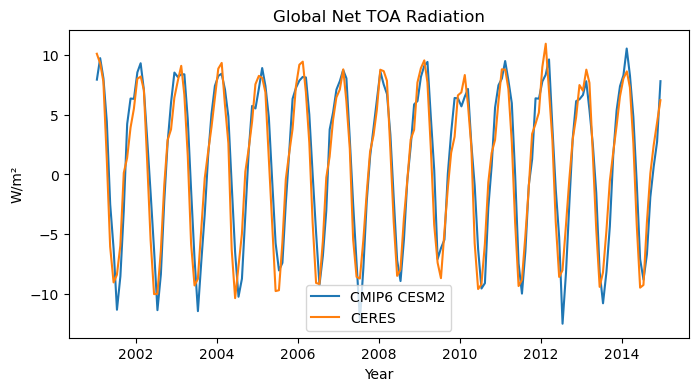

In [26]:
plt.figure(figsize=(8,4))

model_net_global.plot(label="CMIP6 CESM2")
ceres_net_global.plot(label="CERES")

plt.xlabel("Year")

plt.legend()
plt.title("Global Net TOA Radiation")
plt.ylabel("W/m²")

plt.show()